# Deliverable 1

# Nutritional adequacy of diet (Deliverable 3)

# Consumer Demand Model — Panama
## Research Question
**Do higher prices of nutrient-rich foods cause substitution toward calorie-dense foods, and are rural and child-heavy households more affected?**

This notebook extends the rough draft to:
1. Map food items to nutritional content using the Central American FCT
2. Compute per-household nutrient adequacy ratios vs. US/WHO RDAs
3. Analyze price-driven substitution (nutrient-rich → calorie-dense)
4. Decompose effects by rural status and household child composition

## 0. Setup

In [ ]:
%pip install -q eep153_tools scikit-learn statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Load Panama Survey Data

We load three waves of Panama's household expenditure survey (1997, 2003, 2008). Each row in the expenditure data represents **one food item purchased by one household in one survey period**. The key columns are:

- `i` — household ID
- `t` / `m` — year and region code
- `j` — food item name (e.g. "Arroz", "Frijoles")
- `Expenditure` — money spent on that food

We also load **food prices** (price per kg, by region and year) and **household characteristics** (size, demographics, rural/urban flag). Note: the 2008 price sheet is empty, so prices only cover 1997 and 2003.

In [ ]:
PANAMA_FILE = 'Panama.xlsx'   # update path if needed
FCT_FILE    = 'central_american_fct_-_FCT.csv'

def load_expenditures(year):
    df = pd.read_excel(PANAMA_FILE, sheet_name=f'Food Expenditures ({year})')
    return df

x97 = load_expenditures(1997)
x03 = load_expenditures(2003)
x08 = load_expenditures(2008)
xall = pd.concat([x97, x03, x08], ignore_index=True)

def load_prices(year):
    df = pd.read_excel(PANAMA_FILE, sheet_name=f'Food Prices ({year})')
    if df.empty:
        return df
    return df[df['u'] == 'kg'].groupby(['t','m','j'])['Price'].median().reset_index()

p97 = load_prices(1997)
p03 = load_prices(2003)
pall = pd.concat([p97, p03], ignore_index=True)

d = pd.read_excel(PANAMA_FILE, sheet_name='Household Characteristics')
d = d.replace(np.nan, 0)

reg = pd.read_excel(PANAMA_FILE, sheet_name='Region Features')

print('Expenditure rows:', len(xall))
print('Price rows:', len(pall))
print('Households:', len(d))
print('Unique foods:', xall['j'].nunique())
print('\nSurvey years covered:')
print(xall['t'].value_counts().sort_index())
print('\nRegions in data (top 10):')
print(reg['m'].value_counts().head(10))

## 2. Load & Clean the Central American Food Composition Table (FCT)

The FCT is a reference table that records the nutritional content of each food **per 100g**. For example: 100g of white rice contains ~365 kcal, ~7g protein, ~0.4mg iron, and so on.

We rename the columns into short descriptive names, drop section-header rows (which have no food code), and coerce all nutrient columns to numeric values. The result is a clean lookup table we can join against our expenditure data.

In [ ]:
raw_fct = pd.read_csv(FCT_FILE)

# Row 0 is units; actual data starts at row 3 (index 3)
fct = raw_fct.iloc[3:].copy()
fct.columns = [
    'code', 'food_name', 'water_pct',
    'energy_kcal', 'protein_g', 'fat_g', 'carbs_g',
    'fiber_g', 'ash_g', 'calcium_mg', 'phosphorus_mg',
    'iron_mg', 'thiamine_mg', 'riboflavin_mg', 'niacin_mg',
    'vit_c_mg', 'vit_a_re', 'mufa_g', 'pufa_g', 'sfa_g',
    'cholesterol_mg', 'potassium_mg', 'sodium_mg', 'zinc_mg',
    'magnesium_mg', 'vit_b6_mg', 'vit_b12_ug', 'folic_acid_ug',
    'folate_dfe_ug', 'edible_fraction'
]

fct = fct.dropna(subset=['code']).reset_index(drop=True)

num_cols = fct.columns.drop(['code','food_name'])
fct[num_cols] = fct[num_cols].apply(pd.to_numeric, errors='coerce')

print(f'FCT loaded: {len(fct)} foods, {len(fct.columns)} columns')
print('\nSample — nutrients per 100g of food:')
fct[['food_name','energy_kcal','protein_g','iron_mg','vit_c_mg','vit_a_re','calcium_mg']].head(8)

## 3. Map Survey Foods → FCT Entries

The survey tracks broad food categories (e.g. "Arroz") not specific FCT items. `FOOD_MAP` manually links each survey food to the most representative FCT keyword.

The `lookup_fct()` function searches the FCT for rows whose name contains that keyword (case-insensitive) and returns the **mean** nutrient values across all matches, giving us a nutritional profile for each survey food. Items that are non-food (tobacco, liquor) are mapped to `None` and excluded.

In [ ]:
FOOD_MAP = {
    'Aceite Vegetal':               'ACEITE VEGETAL',
    'Aguacates':                    'AGUACATE',
    'Ahí Verde':                    'AJÍ VERDE',
    'Ajo':                          'AJO',
    'Apio':                         'APIO',
    'Arroz':                        'ARROZ, BLANCO',
    'Arvejas':                      'ARVEJA',
    'Azúcar':                       'AZÚCAR, BLANCA',
    'Café Y Té':                    'CAFÉ',
    'Carne De Res':                 'CARNE DE RES',
    'Carnes De Puerco':             'CARNE DE CERDO',
    'Cebolla':                      'CEBOLLA',
    'Cereales Y Cremas':            'HARINA DE MAÍZ',
    'Cervezas':                     'CERVEZA',
    'Chocolates':                   'CHOCOLATE',
    'Cocos (Pipas)':               'COCO',
    'Condimentos':                  'CULANTRO',
    'Culanto, Perejil, Cebollina':  'CULANTRO',
    'Embutidos':                    'SALCHICHA',
    'Enlatados Y Envasados':        'ATÚN EN LATA',
    'Frijoles':                     'FRIJOL NEGRO',
    'Galletas / Pasteles Y Dulces': 'GALLETA',
    'Gelatinas':                    'GELATINA',
    'Guineos (Bananos)':            'BANANO',
    'Harina De Trigo':              'HARINA DE TRIGO',
    'Helados':                      'HELADO',
    'Huevos De Gallina':            'HUEVO DE GALLINA',
    'Lecha Evaporada':              'LECHE DE VACA',
    'Leche En Polvo':               'LECHE DE VACA',
    'Leche Líquida':                'LECHE DE VACA',
    'Lechuga':                      'LECHUGA',
    'Lentejas':                     'LENTEJA',
    'Limones':                      'LIMÓN',
    'Mangos':                       'MANGO',
    'Manteca':                      'MANTECA DE CERDO',
    'Mantequilla':                  'MANTEQUILLA',
    'Mariscos':                     'CAMARÓN',
    'Maíz':                         'MAÍZ',
    'Melón':                        'MELÓN',
    'Nabo':                         'NABO',
    'Naranjas':                     'NARANJA',
    'Otras Carnes':                 'POLLO',
    'Otras Frutas':                 'PAPAYA',
    'Otras Legumbres':              'ARVEJA',
    'Otras Verduras Y Hortalizas':  'REPOLLO',
    'Otros Lácteos':                'QUESO',
    'Pan':                          'PAN BLANCO',
    'Papa':                         'PAPA',
    'Papaya':                       'PAPAYA',
    'Pastas':                       'PASTA',
    'Pepino':                       'PEPINO',
    'Pescados':                     'PESCADO',
    'Piña':                         'PIÑA',
    'Plátanos':                     'PLÁTANO',
    'Pollo':                        'POLLO',
    'Queso':                        'QUESO',
    'Refrescos Y Bebidas':          'BEBIDA CARBONATADA',
    'Repollo':                      'REPOLLO',
    'Sandía':                       'SANDÍA',
    'Tomate':                       'TOMATE',
    'Tortillas':                    'TORTILLA DE MAÍZ',
    'Uvas':                         'UVA',
    'Yuca':                         'YUCA',
    'Zanahoria':                    'ZANAHORIA',
    'Zapallo':                      'ZAPALLO',
    'Alimento Infantil':            'LECHE DE VACA',
    'Cigarrillo Y Tabaco':          None,
    'Licores Varios':               None,
}

def lookup_fct(keyword):
    """Return mean nutrients for FCT rows whose food_name contains keyword."""
    if keyword is None:
        return None
    mask = fct['food_name'].str.upper().str.contains(keyword.upper(), na=False)
    hits = fct[mask]
    if hits.empty:
        return None
    return hits[num_cols].mean()

rows = []
for survey_food, kw in FOOD_MAP.items():
    nut = lookup_fct(kw)
    if nut is not None:
        row = nut.to_dict()
        row['j'] = survey_food
        row['fct_match'] = kw
        rows.append(row)

nut_df = pd.DataFrame(rows).set_index('j')
print(f'Mapped {len(nut_df)} of {len(FOOD_MAP)} survey foods to FCT')
print('\nNutritional content per 100g — first 10 foods:')
nut_df[['fct_match','energy_kcal','protein_g','iron_mg','vit_c_mg','vit_a_re','calcium_mg']].head(10)

## 4. Classify Foods: Nutrient-Rich vs. Calorie-Dense

Not all calories are equal. We want to distinguish foods that deliver lots of micronutrients per calorie (e.g. fish, beans, vegetables) from foods that are pure energy with few micronutrients (e.g. oil, sugar, refined starches).

### How the Nutrient Density Index (NDI) works

1. For each food, compute how much **protein, iron, vitamin C, and vitamin A** it delivers **per 100 kcal** — this normalises for caloric content.
2. **Z-score** each of these four measures (subtract mean, divide by standard deviation) so they are on a comparable scale regardless of their units.
3. **Average** the four z-scores into one NDI. Higher NDI = more nutrients per calorie.
4. **Label** the top 40% as `nutrient_rich` and the bottom 40% as `calorie_dense`.

This classification is what drives the main research question: when nutrient-rich foods get expensive, do households shift spending toward calorie-dense foods?

In [ ]:
nut = nut_df.copy()
kcal = nut['energy_kcal'].replace(0, np.nan)

nut['protein_per100kcal'] = nut['protein_g'] / kcal * 100
nut['iron_per100kcal']    = nut['iron_mg']   / kcal * 100
nut['vitC_per100kcal']    = nut['vit_c_mg']  / kcal * 100
nut['vitA_per100kcal']    = nut['vit_a_re']  / kcal * 100

density_cols = ['protein_per100kcal','iron_per100kcal','vitC_per100kcal','vitA_per100kcal']
nut['ndi'] = nut[density_cols].apply(lambda c: (c - c.mean()) / c.std()).mean(axis=1)

thresh_hi = nut['ndi'].quantile(0.60)
thresh_lo = nut['ndi'].quantile(0.40)
nut['category'] = 'neutral'
nut.loc[nut['ndi'] >= thresh_hi, 'category'] = 'nutrient_rich'
nut.loc[nut['ndi'] <= thresh_lo, 'category'] = 'calorie_dense'

# FIX: write category back to nut_df so it is available in later cells
nut_df['category'] = nut['category']

print('Foods per category:')
print(nut['category'].value_counts())

print('\n--- TOP NUTRIENT-RICH FOODS (most micronutrients per calorie) ---')
print(nut[nut['category']=='nutrient_rich'][['ndi','fct_match']].sort_values('ndi', ascending=False).head(10))

print('\n--- TOP CALORIE-DENSE FOODS (fewest micronutrients per calorie) ---')
print(nut[nut['category']=='calorie_dense'][['ndi','fct_match']].sort_values('ndi').head(10))

In [ ]:
# ── Visualise the food classification ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'nutrient_rich': 'steelblue', 'neutral': 'lightgray', 'calorie_dense': 'darkorange'}
ndis = nut['ndi'].values
cats = nut['category'].values
bar_colors = [colors[c] for c in cats]
sorted_idx = np.argsort(ndis)[::-1]

ax.bar(range(len(ndis)), ndis[sorted_idx],
       color=[bar_colors[i] for i in sorted_idx], edgecolor='white', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  label='Nutrient-rich (top 40% NDI) — e.g. fish, legumes, vegetables'),
    Patch(facecolor='lightgray',  label='Neutral (middle 20%)'),
    Patch(facecolor='darkorange', label='Calorie-dense (bottom 40% NDI) — e.g. oils, sugar, refined starches'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
ax.set_xlabel('Foods ranked by Nutrient Density Index (highest → lowest)')
ax.set_ylabel('Nutrient Density Index (NDI)')
ax.set_title(
    'Food Classification by Nutrient Density\n'
    'NDI = average z-scored protein + iron + vit C + vit A per 100 kcal'
)
ax.set_xticks([])
plt.tight_layout()
plt.savefig('food_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Each bar is one food. Tall blue bars = very nutrient-dense (lots of micronutrients per calorie).')
print('Short orange bars = calorie-dense but micronutrient-poor.')

## 5. Compute Household-Level Nutrient Intakes

We now convert spending data into actual nutrition consumed, in three steps:

**Step 1 — Spending → Quantity (kg):**  
Quantity = Expenditure ÷ Price per kg.  
When a household's local price is missing, we substitute the median price for that food across all regions and years.

**Step 2 — Quantity → Nutrients:**  
FCT values are per 100g, so we multiply kg × 10 to get per-100g units, then multiply by the nutrient value. For example:  
> 2 kg of rice × 10 × 7g protein/100g = 140g protein from rice.

**Step 3 — Aggregate to household-month, then per-capita daily:**  
Sum all foods for the same household in the same month, then divide by household size × 30 days to get **per-person per-day intakes**.

> Dividing by household size matters: a family of 8 buying the same food as a family of 2 has only ¼ as much food per person.

In [ ]:
xall2 = xall.copy()

# Aggregate duplicate entries per household-food
xall2 = xall2.groupby(['i','t','m','j'], as_index=False)['Expenditure'].sum()

# Attach prices
xall2 = xall2.merge(pall.rename(columns={'Price':'price_kg'}), on=['t','m','j'], how='left')

# Fill missing prices with global median per food
global_price = xall2.groupby('j')['price_kg'].median()
xall2['price_kg'] = xall2['price_kg'].fillna(xall2['j'].map(global_price))
xall2['qty_kg'] = xall2['Expenditure'] / xall2['price_kg'].replace(0, np.nan)

# Attach nutritional content (note: use nut which has 'category')
key_nutrients = ['energy_kcal','protein_g','iron_mg','vit_c_mg','vit_a_re','calcium_mg']
xall2 = xall2.merge(
    nut[key_nutrients + ['category']].reset_index(),
    on='j', how='left'
)

# Total nutrients = qty_kg * (nutrient per 100g) * 10
for col in key_nutrients:
    xall2[f'total_{col}'] = xall2['qty_kg'] * xall2[col] * 10

print('Row count after merges:', xall2.shape)
print('Missing qty (no price available):', xall2['qty_kg'].isna().sum(), 'rows')
print('\nSample — each row = one food bought by one household:')
xall2[['i','t','j','qty_kg','total_energy_kcal','category']].head(8)

In [ ]:
# Aggregate to household-month level
total_cols = [f'total_{c}' for c in key_nutrients]
hh_nut = xall2.groupby(['i','t','m'])[total_cols + ['Expenditure']].sum().reset_index()

# Merge household characteristics and rural flag
hh_nut = hh_nut.merge(d, on=['i','t','m'], how='left')
hh_nut = hh_nut.merge(reg[['i','t','m','Rural']], on=['i','t','m'], how='left')

# Household size (stored as log in the data)
hh_nut['hsize'] = np.exp(hh_nut['log HSize'])

# Per-capita daily intakes
SURVEY_DAYS = 30
for col in total_cols:
    hh_nut[f'pc_{col}'] = hh_nut[col] / (hh_nut['hsize'] * SURVEY_DAYS)

print('Total household-months with nutrient data:', len(hh_nut))
print('\nPer-capita daily intakes — summary statistics:')
pc_cols = [f'pc_{c}' for c in total_cols]
hh_nut[pc_cols].describe().round(1)

## 6. Dietary Adequacy: Comparing to Recommended Daily Allowances (RDA)

### How adequacy is measured

A **Nutrient Adequacy Ratio (NAR)** is:

> **NAR = per-capita daily intake ÷ Recommended Daily Allowance**

| NAR value | Meaning |
|---|---|
| 1.0 | Household meets 100% of the recommendation |
| 0.7 | Meets 70% — our adequacy threshold |
| 0.5 | Only gets half the recommendation |
| > 1.0 | Exceeds the recommendation (capped at 1.5) |

We use **US/WHO Dietary Reference Intakes (DRI)** as reference values (2000 kcal, 50g protein, 10mg iron, 75mg vit C, 750μg vit A, 1000mg calcium per day).

The **Mean Adequacy Ratio (MAR)** averages NARs across all six nutrients into one number summarising overall diet quality. MAR = 1.0 would mean the household meets every RDA on average.

A household is flagged as **adequate** for a nutrient if NAR ≥ 0.70 (70% of RDA). Below 70%, the risk of clinical deficiency becomes meaningful in nutrition literature.

In [ ]:
RDA = {
    'pc_total_energy_kcal': 2000,
    'pc_total_protein_g':   50,
    'pc_total_iron_mg':     10,
    'pc_total_vit_c_mg':    75,
    'pc_total_vit_a_re':    750,
    'pc_total_calcium_mg':  1000,
}

for pcol, rda in RDA.items():
    nar_col = pcol.replace('pc_total_', 'nar_')
    hh_nut[nar_col] = (hh_nut[pcol] / rda).clip(upper=1.5)

nar_cols = [c.replace('pc_total_', 'nar_') for c in RDA.keys()]
nutrient_labels = {
    'nar_energy_kcal': 'Energy', 'nar_protein_g': 'Protein',
    'nar_iron_mg': 'Iron', 'nar_vit_c_mg': 'Vitamin C',
    'nar_vit_a_re': 'Vitamin A', 'nar_calcium_mg': 'Calcium'
}

hh_nut['MAR'] = hh_nut[nar_cols].mean(axis=1)

THRESHOLD = 0.70
for nar_col in nar_cols:
    hh_nut[f'adeq_{nar_col}'] = (hh_nut[nar_col] >= THRESHOLD).astype(int)

print('Mean NAR across all households (1.0 = meets RDA exactly):')
for nar_col in nar_cols:
    mean_nar  = hh_nut[nar_col].mean()
    pct_adeq  = (hh_nut[nar_col] >= THRESHOLD).mean() * 100
    print(f'  {nutrient_labels[nar_col]:12s}: mean NAR = {mean_nar:.2f}  |  {pct_adeq:.1f}% of households adequate')
print(f'\nOverall MAR (average across all 6 nutrients): {hh_nut["MAR"].mean():.3f}')
print('(1.0 would mean all households meet all RDAs on average)')

### 6a. Overall dietary adequacy — what share of households meet each recommendation?

The chart below shows the **percentage of households** meeting ≥70% of the RDA for each nutrient. Colour indicates severity:

- 🟢 **Green** — most households are adequate (bar > 75%)
- 🟡 **Orange** — moderate concern (50–75%)
- 🔴 **Red** — widespread deficiency risk (< 50%)

Nutrients with short bars are the dietary bottlenecks for this population.

In [ ]:
adequacy_rates = {}
for nar_col in nar_cols:
    pct = (hh_nut[nar_col] >= THRESHOLD).mean() * 100
    adequacy_rates[nutrient_labels[nar_col]] = pct

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['#d9534f' if v < 50 else '#f0ad4e' if v < 75 else '#5cb85c'
              for v in adequacy_rates.values()]
bars = ax.barh(list(adequacy_rates.keys()), list(adequacy_rates.values()),
               color=colors_bar, edgecolor='white')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% of households')
ax.axvline(75, color='orange', linestyle='--', alpha=0.5, label='75% of households')
ax.set_xlabel('% of households meeting ≥70% of RDA')
ax.set_title(
    'Overall Dietary Adequacy in Panama (all years & regions combined)\n'
    'Green = broad adequacy | Orange = moderate concern | Red = widespread deficiency'
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, adequacy_rates.values()):
    ax.text(min(bar.get_width() + 0.5, 98), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend(loc='lower right')
ax.set_xlim(0, 108)
plt.tight_layout()
plt.savefig('adequacy_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### 6b. Adequacy by Rural vs. Urban

Rural households may face lower incomes, fewer food options, and heavier reliance on local staples. This comparison tests whether rural location predicts worse dietary adequacy, and by how much for each nutrient.

In [ ]:
for_plot = []
for rural_val, label in [(0,'Urban'), (1,'Rural')]:
    sub = hh_nut[hh_nut['Rural'] == rural_val]
    rates = {nutrient_labels[c]: (sub[c] >= THRESHOLD).mean() * 100 for c in nar_cols}
    rates['group'] = label
    rates['n'] = len(sub)
    for_plot.append(rates)

plot_df = pd.DataFrame(for_plot).set_index('group')
n_urban = int(plot_df.loc['Urban','n'])
n_rural = int(plot_df.loc['Rural','n'])
plot_df = plot_df.drop(columns='n').T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
ax.bar(x - w/2, plot_df['Urban'], w, label=f'Urban (n={n_urban:,})', color='steelblue')
ax.bar(x + w/2, plot_df['Rural'],  w, label=f'Rural  (n={n_rural:,})',  color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15)
ax.set_ylabel('% of households meeting ≥70% of RDA')
ax.set_title(
    'Dietary Adequacy: Urban vs. Rural Households\n'
    'Each bar = % of households in that group meeting the minimum recommendation'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(50, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax.legend()
plt.tight_layout()
plt.savefig('adequacy_rural_urban.png', dpi=150, bbox_inches='tight')
plt.show()

print('Urban vs Rural gap (positive = Urban households do better):')
gap = (plot_df['Urban'] - plot_df['Rural']).round(1)
for nutrient, diff in gap.items():
    direction = 'Urban advantage' if diff > 0 else 'Rural advantage'
    print(f'  {nutrient:12s}: {diff:+.1f} pp  ({direction})')

### 6c. Adequacy by Region

Different regions of Panama may have very different food environments, prices, and income levels. This chart breaks adequacy rates out by region (the `m` variable), letting us identify geographic hotspots of dietary risk.

In [ ]:
region_adequacy = []
regions = sorted(hh_nut['m'].dropna().unique())

for region in regions:
    sub = hh_nut[hh_nut['m'] == region]
    if len(sub) < 10:
        continue
    row = {'region': str(region), 'n': len(sub)}
    for nar_col in nar_cols:
        row[nutrient_labels[nar_col]] = (sub[nar_col] >= THRESHOLD).mean() * 100
    row['MAR_mean'] = sub['MAR'].mean()
    row['Rural_pct'] = sub['Rural'].mean() * 100
    region_adequacy.append(row)

reg_df = pd.DataFrame(region_adequacy).set_index('region')
nutrient_order = list(nutrient_labels.values())

fig, ax = plt.subplots(figsize=(max(10, len(reg_df)*1.4), 6))
x = np.arange(len(reg_df))
width = 0.13
palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
for i, (nut_name, col) in enumerate(zip(nutrient_order, palette)):
    offset = (i - len(nutrient_order)/2 + 0.5) * width
    ax.bar(x + offset, reg_df[nut_name], width, label=nut_name, color=col, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'Region {r}\n(n={reg_df.loc[r,"n"]}, {reg_df.loc[r,"Rural_pct"]:.0f}% rural)'
     for r in reg_df.index],
    rotation=30, ha='right', fontsize=8
)
ax.set_ylabel('% of households meeting ≥70% of RDA')
ax.set_title(
    'Dietary Adequacy by Region\n'
    'Each cluster = one region; bars = % adequate for each nutrient; label shows sample size & % rural'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(50, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax.legend(loc='lower right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('adequacy_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRegion summary — sorted by overall diet quality (MAR):')
print('(MAR closer to 1.0 = better diet quality; Rural_pct = % of households that are rural)')
summary_cols = ['n', 'Rural_pct', 'MAR_mean'] + nutrient_order
print(reg_df[summary_cols].sort_values('MAR_mean', ascending=False).round(1).to_string())

### 6d. Rural vs. Urban adequacy *within* each Region

So far we've seen rural/urban differences overall, and regional differences overall. But these factors interact: a region could be rural *and* have a poor food environment. 

The heatmap below shows the **Mean Adequacy Ratio (MAR)** for urban and rural households separately within each region. This reveals:

- **Column variation** → which regions have worse diets overall
- **Row variation within a column** → how large the rural-urban gap is in that region

Colour scale: 🟢 green = high MAR (adequate) → 🔴 red = low MAR (deficient).

In [ ]:
pivot_data = []
for region in regions:
    for rural_val, label in [(0,'Urban'), (1,'Rural')]:
        sub = hh_nut[(hh_nut['m'] == region) & (hh_nut['Rural'] == rural_val)]
        if len(sub) < 5:
            continue
        pivot_data.append({
            'Region': str(region),
            'Group': label,
            'MAR': sub['MAR'].mean(),
            'n': len(sub)
        })

pivot_df = pd.DataFrame(pivot_data)
heatmap_data = pivot_df.pivot(index='Group', columns='Region', values='MAR')

fig, ax = plt.subplots(figsize=(max(8, len(heatmap_data.columns)*1.1), 4))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f'Region {c}' for c in heatmap_data.columns], rotation=40, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            text_color = 'black' if 0.45 < val < 0.85 else 'white'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color=text_color, fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean Adequacy Ratio (MAR)  [1.0 = fully meets all RDAs]', shrink=0.8)
ax.set_title(
    'Mean Adequacy Ratio by Region and Rural/Urban Status\n'
    'Greener = better diet quality | Redder = greater deficiency risk'
)
plt.tight_layout()
plt.savefig('mar_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('How to read this:')
print('  Each cell = average MAR for Urban or Rural households in that region.')
print('  A large gap between the two rows in the same column = big rural-urban diet inequality in that region.')
print('  Columns that are uniformly red = regions with poor food access regardless of urban/rural status.')

### 6e. Per-nutrient adequacy by Region and Rural/Urban status

The heatmap above shows overall diet quality (MAR). Here we drill into each individual nutrient to see *where* and *which* gaps are largest.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, nar_col in zip(axes, nar_cols):
    nut_name = nutrient_labels[nar_col]
    region_vals = {'region': [], 'Urban': [], 'Rural': [], 'gap': []}

    for region in regions:
        u_sub = hh_nut[(hh_nut['m'] == region) & (hh_nut['Rural'] == 0)]
        r_sub = hh_nut[(hh_nut['m'] == region) & (hh_nut['Rural'] == 1)]
        if len(u_sub) < 5 or len(r_sub) < 5:
            continue
        u_rate = (u_sub[nar_col] >= THRESHOLD).mean() * 100
        r_rate = (r_sub[nar_col] >= THRESHOLD).mean() * 100
        region_vals['region'].append(str(region))
        region_vals['Urban'].append(u_rate)
        region_vals['Rural'].append(r_rate)
        region_vals['gap'].append(u_rate - r_rate)

    if not region_vals['region']:
        ax.set_visible(False)
        continue

    r_df = pd.DataFrame(region_vals).set_index('region')
    x_pos = np.arange(len(r_df))
    ax.bar(x_pos - 0.2, r_df['Urban'], 0.38, label='Urban', color='steelblue', alpha=0.85)
    ax.bar(x_pos + 0.2, r_df['Rural'], 0.38, label='Rural',  color='darkorange', alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'R{r}' for r in r_df.index], fontsize=8)
    ax.set_title(nut_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('% adequate', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.axhline(50, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_ylim(0, 110)
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle(
    'Adequacy Rate by Nutrient, Region, and Rural/Urban Status\n'
    '(Each panel = one nutrient | Blue = Urban | Orange = Rural | Red dashed = 50% adequacy line)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('adequacy_nutrient_region_rural.png', dpi=150, bbox_inches='tight')
plt.show()

### 6f. Summary Table: Dietary Adequacy Across Sub-Groups

A consolidated view of key adequacy metrics. The `MAR (mean)` column gives the single best summary of overall diet quality for each group.

In [ ]:
# Add child-heavy flag
child_cols_d = [c for c in hh_nut.columns if any(age in c for age in ['00-03','04-08','09-13'])]
if child_cols_d:
    hh_nut['n_children'] = hh_nut[child_cols_d].sum(axis=1)
    hh_nut['child_heavy'] = (hh_nut['n_children'] >= 2).astype(int)
else:
    hh_nut['child_heavy'] = 0

summary_rows = []
groups = [
    ('All households',                 hh_nut),
    ('Urban',                          hh_nut[hh_nut['Rural'] == 0]),
    ('Rural',                          hh_nut[hh_nut['Rural'] == 1]),
    ('Child-heavy (≥2 children u14)',  hh_nut[hh_nut['child_heavy'] == 1]),
    ('Low/no children',                hh_nut[hh_nut['child_heavy'] == 0]),
]

for label, sub in groups:
    if len(sub) == 0:
        continue
    row = {'Group': label, 'N': len(sub), 'MAR (mean)': round(sub['MAR'].mean(), 3)}
    for nar_col in nar_cols:
        pct = (sub[nar_col] >= THRESHOLD).mean() * 100
        row[f'% adeq {nutrient_labels[nar_col]}'] = f'{pct:.1f}%'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Group')
print('=== Dietary Adequacy Summary ===')
print('MAR (mean): average Nutrient Adequacy Ratio across all 6 nutrients — closer to 1.0 is better')
print('% adeq columns: % of households in that group meeting ≥70% of the RDA')
print()
display(summary_df)

## 7. Price-Driven Substitution Analysis
*(see original cells below)*

# Estimate Demand System (Deliverable 4)

### Consumer Demand Model

In [6]:
!pip install -r requirements-est.txt
%pip install CFEDemands
# %pip install eep153_tools

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
x = pd.read_csv('data/Panama - Food Expenditures (2003).csv')
p = pd.read_csv('data/Panama - Food Prices (2003).csv')
d = pd.read_csv('data/Panama - Household Characteristics (2003).csv')
import numpy as np

In [8]:
Panama_data = '1tYmqzz4VqM5rd4aeO6zB4wL9ADcoTdvTPKZF5zgX7a4'

In [11]:
x = x.set_index(['i','t','m','j']).squeeze()

# Compute medians of prices for particular time, place and unit
p = p.groupby(['t','m','j','u']).median()

# Just keep metric units
p = p.xs('kg',level="u").squeeze().unstack('j')

# Get intersection of goods we have prices *and* expenditures for:
jidx = p.columns.intersection(x.index.levels[-1])

# Drop prices for goods we don't have expenditures for
p = p[jidx].T

# Household characteristics
d.columns.name = 'k'

# Fill blanks with zeros
d = d.replace(np.nan,0)

# Expenditures x may have duplicate columns
x = x.T.groupby(['i','t','m','j']).sum()
x = x.replace(0,np.nan) # Replace zeros with missing

# Take logs of expenditures; call this y
y = np.log(x)

d.set_index(['i','t','m'],inplace=True)

In [13]:
d.head()

,,k,men,women,girls,boys,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
i,t,m,,,,,,,,,,,,,,,,,,,
1997125,1997,Herrera,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1.098612
1997160,1997,Herrera,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1.098612
1997170,1997,Bocas Del Toro,1,1,4,3,1,2,1,0,0,1,1,1,0,0,0,1,1,0,2.197225
1997177,1997,Bocas Del Toro,1,4,5,9,2,1,4,1,1,3,2,0,0,2,0,2,1,0,2.944439
1997178,1997,Bocas Del Toro,2,2,2,1,0,0,0,1,1,0,0,1,2,0,0,1,0,1,1.945910


In [14]:
y.head()

i        t     m      j             
2003199  2003  Colón  Aceite Vegetal    0.559616
                      Ahí Verde        -1.386294
                      Apio             -1.897120
                      Arroz             1.266948
                      Azúcar            0.438255
Name: Expenditure, dtype: float64

In [15]:
from cfe import Regression

result = Regression(y=y,d=d)

In [16]:
result.predicted_expenditures()

i         t     m        j                       
2003199   2003  Colón    Aceite Vegetal              2.606201
                         Ajo                         0.611317
                         Arroz                       5.702980
                         Azúcar                      1.648507
                         Café Y Té                   1.540986
                                                       ...   
20039596  2003  Herrera  Sal                         0.431861
                         Sardina Y Atún              2.184535
                         Sodas, Refrescos Y Jugos    3.889362
                         Tomate                      1.528868
                         Yuca                        0.678699
Length: 195294, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

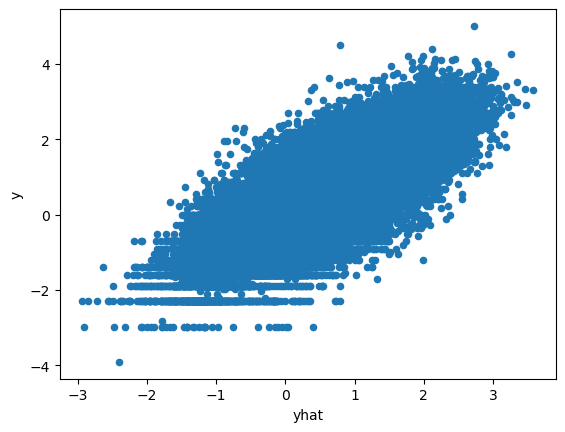

In [17]:
%matplotlib inline
df = pd.DataFrame({'y':y,'yhat':result.get_predicted_log_expenditures()})
df.plot.scatter(x='yhat',y='y')

# Counterfactual Experiments (Deliverable 5)